In [ ]:
!pip install git+https://github.com/openai/CLIP.git
!pip install livelossplot

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-sb3vtr7a
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-sb3vtr7a
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=b766e524d6a54e61886785702d4f7fe802ce4341169a20edd1a4140c4164ee7c
  Stored in directory: /tmp/pip-ephem-wheel-cache-x7zfamtr/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
# standard library imports
import os
import json
import shutil
import zipfile

# pytoch & utilities
import torch
import torch.nn as nn
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

# clip
import clip

# third-party library imports
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from google.colab import drive
from PIL import Image
import torchvision.transforms as T
import numpy as np

# evaluation & logging
from sklearn.metrics import f1_score
from livelossplot import PlotLosses

In [95]:
label_map = {
    'bike': 1,
    'bus': 2,
    'car': 3,
    'drivable area': 4,
    'lane': 5,
    'motor': 6,
    'person': 7,
    'rider': 8,
    'traffic light': 9,
    'traffic sign': 10,
    'train': 11,
    'truck': 12
}

reasons = [
    'Traffic light is green',
    'Follow traffic',
    'Road is clear',
    'Traffic light',
    'Traffic sign',
    'Obstacle: car',
    'Obstacle: person',
    'Obstacle: rider',
    'Obstacle: others',
    'No lane on the left',
    'Obstacles on the left lane',
    'Solid line on the left',
    'On the left-turn lane',
    'Traffic light allows',
    'Front car turning left',
    'No lane on the right',
    'Obstacles on the right lane',
    'Solid line on the right',
    'On the right-turn lane',
    'Traffic light allows',
    'Front car turning right'
]

id_to_label = {v: k for k, v in label_map.items()}

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
"""
This cell loads the BDD-OIA dataset from Google Drive into
Google Colab's local working directory.
"""
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/COMP646_Final_Project/BDD-OIA.zip'
local_zip = '/content/BDD-OIA.zip'
extract_to = 'content/BDD-OIA'

shutil.copyfile(zip_path, local_zip)

with zipfile.ZipFile(local_zip, 'r') as zip_ref:
  zip_ref.extractall(extract_to)

Mounted at /content/drive


In [ ]:
# load pre-trained CLIP
clip_backbone, preprocess = clip.load("ViT-B/32", device=device)
clip_backbone = clip_backbone.float()

100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 90.6MiB/s]


In [ ]:
class OIAInferenceDataset(Dataset):
  def __init__(self, data_list, images_dir):
    self.data_list = data_list
    self.images_dir = images_dir
    self.transform = T.Compose([T.ToTensor()])

  def __len__(self):
    return len(self.data_list)

  def __getitem__(self, idx):
    file_name = self.data_list[idx]["file_name"]
    img_path = os.path.join(self.images_dir, file_name)
    img = Image.open(img_path).convert("RGB")
    return self.transform(img), idx

class BDDOIAAnnotatedDataset(Dataset):
  def __init__(self, data_list, images_dir, preprocess, max_scene_objects=10):
    self.data_list = data_list
    self.images_dir = images_dir
    self.preprocess = preprocess
    self.max_scene_objects = max_scene_objects
    self.grid_labels = [
        ["top-left",     "top-center",    "top-right"],
        ["middle-left",  "middle-center", "middle-right"],
        ["bottom-left", "bottom-center", "bottom-right"]
    ]

  def __len__(self):
    return len(self.data_list)

  def get_grid_pos(self, box, w, h):
    """
    Given a bounding box, this function determines which cell of a
    3x3 grid the bounding box falls in.
    """
    x, y = (box[0] + box[2]) / 2, (box[1] + box[3]) / 2
    col, row = min(int(x / (w / 3)), 2), min(int(y / (h / 3)), 2)
    return self.grid_labels[row][col]

  def pad_crop(self, img, box, padding=0.2):
    """
    Given a bounding box, this function adds padding.
    """
    w, h = img.size
    bw, bh = box[2] - box[0], box[3] - box[1]
    x1, y1 = max(0, box[0] - bw * padding), max(0, box[1] - bh * padding)
    x2, y2 = min(w, box[2] + bw * padding), min(h, box[3] + bh * padding)
    return img.crop((x1, y1, x2, y2))

  def __getitem__(self, idx):
    item = self.data_list[idx]
    img_path = os.path.join(self.images_dir, item["file_name"])
    img = Image.open(img_path).convert("RGB")
    w, h = img.size

    global_img = self.preprocess(img)

    obj_crops = torch.zeros((self.max_scene_objects, 3, 224, 224))
    obj_prompts = []

    scene_objects = item["scene_objects"]["boxes"][:self.max_scene_objects]
    scene_object_labels = item["scene_objects"]["labels"][:self.max_scene_objects]
    for i, scene_object in enumerate(scene_objects):
      crop = self.pad_crop(img, scene_object)
      obj_crops[i] = self.preprocess(crop)

      grid_pos = self.get_grid_pos(scene_object, w, h)
      obj_prompts.append(f"A {id_to_label[scene_object_labels[i]]} in the {grid_pos}")

    while len(obj_prompts) < self.max_scene_objects:
      obj_prompts.append("empty space")

    return {
        "file_name": item['file_name'],
        "global_image": global_img,
        "object_crops": obj_crops,
        "object_prompts": clip.tokenize(obj_prompts),
        "actions": torch.tensor(item['action'], dtype=torch.float32),
        "reasons": torch.tensor(item['reason'], dtype=torch.float32),
        "bounding_boxes": scene_objects,
        "bounding_boxes_labels": scene_object_labels
    }

In [108]:
"""
This cell defines all helper functions used in this notebook.
"""
def visualize_sample(img, boxes, labels, scores, action, reason, weights):
    """
    Visualizes the bounding boxes on an image, overlays an action icon, and
    adds a reason caption.
    """
    id_to_label = {v: k for k, v in label_map.items()}
    fig, ax = plt.subplots(figsize=(15, 9))
    ax.imshow(img)

    for idx in range(len(boxes)):
      label = labels[idx]
      pts = boxes[idx]

      x_min, y_min, x_max, y_max = pts

      importance = weights[idx]
      cmap = cm.get_cmap('coolwarm')
      box_color = cmap(importance)
      width, height = x_max - x_min, y_max - y_min
      rect = patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor=box_color, facecolor=box_color, alpha=0.35)
      ax.text(x_min, y_min - 2, label, color='white', fontsize=9, bbox=dict(facecolor='red', alpha=0.3))
      ax.add_patch(rect)

    action = action.copy()
    action = [-1] + action[0]
    for action_idx in range(len(action)):
      if action[action_idx] == -1 or action[action_idx] == 1 and action_idx <= 4:
        icon = f"/content/content/BDD-OIA/BDD-OIA/action_icons/{action_idx - 1}.png"
        icon_img = plt.imread(icon)
        icon_box = OffsetImage(icon_img, zoom=0.2)
        ab = AnnotationBbox(icon_box, (1200, 650), frameon=False, zorder=10 + action_idx)
        ax.add_artist(ab)

    active_reason_indices = [i for i, val in enumerate(reason) if val == 1]
    reason_text = ", ".join([reasons[idx] for idx in active_reason_indices])
    props = dict(boxstyle='round', facecolor='black', alpha=0.8)
    ax.text(0.5, 0.05, f"Reasons:\n{reason_text}", transform=ax.transAxes, fontsize=12,
            color='white', verticalalignment='bottom', horizontalalignment='center',
            bbox=props, wrap=True)

    ax.set_xlim(0, 1280)
    ax.set_ylim(720, 0)
    plt.axis('off')
    plt.show()

def load_faster_rcnn_model(path):
  """
  Returns a trained model using a checkpoint
  """
  checkpoint = torch.load(path, map_location=device)
  model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
  in_features = model.roi_heads.box_predictor.cls_score.in_features
  model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 13) # 13 classes
  for param in model.parameters():
        param.requires_grad = False
  model.load_state_dict(checkpoint['model_state_dict'])
  model.to(device)
  model.eval()
  return model

def load_reasoning_model(path):
  """
  Returns a trained model using a checkpoint
  """
  checkpoint = torch.load(path, map_location=device)
  model = BDDReasoningModel()
  for param in model.parameters():
        param.requires_grad = False

  model.load_state_dict(checkpoint['model_state_dict'])
  model.to(device)
  model.eval()
  return model

def evaluate_model(model, data_loader):
  model.eval()
  with torch.no_grad():
    all_action_predictions, all_action_targets = [], []
    all_reason_predictions, all_reason_targets = [], []

    for i, data in enumerate(data_loader):
      global_img = data["global_image"].to(device)
      object_crops = data["object_crops"].to(device)
      object_prompts = data["object_prompts"].to(device)
      actions = data["actions"].to(device)
      reasons = data["reasons"].to(device)

      action_logits, reason_logits, _ = model(global_img, object_crops, object_prompts)

      all_action_predictions.append((torch.sigmoid(action_logits) > 0.5).cpu())
      all_action_targets.append(actions.cpu())

      all_reason_predictions.append((torch.sigmoid(reason_logits) > 0.5).cpu())
      all_reason_targets.append(reasons.cpu())

    epoch_action_f1 = f1_score(torch.cat(all_action_targets).numpy(), torch.cat(all_action_predictions).numpy(), average='macro')
    epoch_reason_f1 = f1_score(torch.cat(all_reason_targets).numpy(), torch.cat(all_reason_predictions).numpy(), average='macro')

    return epoch_action_f1, epoch_reason_f1

In [ ]:
def load_bddoia(split, annotation_path=None):
    """
    This function returns a list of objects that contain the file name,
    action, and reasons for the action. Additionally, the function generates
    box annotations for a split if annotations do not already exist.
    """
    merged_data = {}
    base_path = "/content/content/BDD-OIA/BDD-OIA"

    actions_path = os.path.join(base_path, f"{split}_25k_images_actions.json")
    reasons_path = os.path.join(base_path, f"{split}_25k_images_reasons.json")
    annotation_dir = os.path.join(base_path, "annotations")
    images_dir = os.path.join(base_path, "data")

    # load reasons
    reasons = {}
    with open(reasons_path) as file:
      json_reasons = json.load(file)
      for entry in json_reasons:
        reasons[entry["file_name"]] = entry["reason"]

    # load actions and merge reasons
    with open(actions_path) as file:
      json_actions = json.load(file)
      for idx, img in enumerate(json_actions["images"]):
        file_name = img["file_name"]

        merged_data[file_name] = {
            "file_name": file_name,
            "action": json_actions["annotations"][idx]["category"][:4],
            "reason": reasons[file_name],
        }

    merged_data = list(merged_data.values())

    if annotation_path is None:
      batch_size = 8
      annotation_path = f"/content/drive/MyDrive/COMP646_Final_Project/BDD-OIA_{split}_annotations.json"
      dataset = OIAInferenceDataset(merged_data, images_dir)
      loader = DataLoader(dataset, batch_size=batch_size, num_workers=8, pin_memory=True)
      model = load_faster_rcnn_model("/content/drive/MyDrive/COMP646_Final_Project/BDD100K_quarter_epoch_10_4372.pth")

      annotations = []
      for imgs, indicies in loader:
        imgs = list(img.to(device) for img in imgs)
        predictions = model(imgs)

        for i, pred in enumerate(predictions):
          keep = pred['scores'] > 0.5
          idx = indicies[i]

          annotations.append({
              "boxes": pred['boxes'][keep].cpu().numpy().tolist(),
              "labels": pred['labels'][keep].cpu().numpy().tolist(),
              "scores": pred['scores'][keep].cpu().numpy().tolist()
          })

        if (indicies[-1] + 1) % (batch_size * 10) == 0:
          print(f"Progress: {((indicies[-1] + 1) / len(dataset)) * 100:.2f}%")

      with open(annotation_path, 'w') as f:
        json.dump(annotations, f)

    with open(annotation_path) as file:
      json_annotations = json.load(file)
      for (obj, annotations) in zip(merged_data, json_annotations):
        obj["scene_objects"] = annotations

    return list(merged_data)

In [ ]:
# load training dataset
bddoia_train = load_bddoia("train", "/content/drive/MyDrive/COMP646_Final_Project/BDD-OIA_train_annotations.json");
bddoia_train = BDDOIAAnnotatedDataset(bddoia_train, os.path.join("/content/content/BDD-OIA/BDD-OIA", "data"), preprocess)

# load validation dataset
bddoia_val = load_bddoia("val", "/content/drive/MyDrive/COMP646_Final_Project/BDD-OIA_val_annotations.json");
bddoia_val = BDDOIAAnnotatedDataset(bddoia_val, os.path.join("/content/content/BDD-OIA/BDD-OIA", "data"), preprocess)

bddoia_test = load_bddoia("test", "/content/drive/MyDrive/COMP646_Final_Project/BDD-OIA_test_annotations.json");
bddoia_test = BDDOIAAnnotatedDataset(bddoia_test, os.path.join("/content/content/BDD-OIA/BDD-OIA", "data"), preprocess)

In [ ]:
class BDDReasoningModel(nn.Module):
  def __init__(self, num_actions=4, num_reasons=21):
    super().__init__()
    self.clip = clip_backbone
    self.embed_dim = 512

    self.attention = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=8, batch_first=True)

    self.action_head = nn.Linear(self.embed_dim * 2, num_actions)
    self.reason_head = nn.Linear(self.embed_dim * 2, num_reasons)

  def forward(self, global_img, obj_crops, obj_tokens):
    B, N, C, H, W = obj_crops.shape

    with torch.no_grad():
      global_features = self.clip.encode_image(global_img).float() # [B, 512]

      flat_crops = obj_crops.view(-1, C, H, W) # [B * N, C, H, W]
      object_img_features = self.clip.encode_image(flat_crops).float() # [B * N, 512]

      flat_tokens = obj_tokens.view(-1, 77) # [B * N, 77], 77 is the fixed length of CLIP text sequence.
      object_txt_features = self.clip.encode_text(flat_tokens).float() # [B * N, 512]

      fused_features = (object_img_features + object_txt_features) / 2
      fused_features = fused_features.view(B, N, self.embed_dim) # [B, N, 512]

    # attention
    query = global_features.unsqueeze(1) # [B, 1, 512]
    attended_context, weights = self.attention(query, fused_features, fused_features)

    combined = torch.cat([global_features, attended_context.squeeze(1)], dim=-1) # [B, 1024]

    return self.action_head(combined), self.reason_head(combined), weights

In [ ]:
"""
This cell trains the reasoning model.
"""
liveloss = PlotLosses()
liveloss_logs = {}
all_losses = []
val_action_history = []
val_reason_history = []
lr_history = []

train_loader = DataLoader(bddoia_train, batch_size=32, num_workers=8, shuffle=True)
val_loader = DataLoader(bddoia_val, batch_size=32, num_workers=8, shuffle=True)

model = BDDReasoningModel().to(device)
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4
)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=2)
criterion = nn.BCEWithLogitsLoss()

num_epochs = 20

for epoch in range(num_epochs):
  model.train()
  total_loss = 0

  for i, data in enumerate(train_loader):
    global_img = data["global_image"].to(device)
    object_crops = data["object_crops"].to(device)
    object_prompts = data["object_prompts"].to(device)
    actions = data["actions"].to(device)
    reasons = data["reasons"].to(device)

    optimizer.zero_grad()
    act_pred, reas_pred, _ = model(global_img, object_crops, object_prompts)
    loss = criterion(act_pred, actions) + (2 * criterion(reas_pred, reasons))
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

    if i % 100 == 0:
      all_losses.append(loss.item())
      print(f"[Epoch {epoch+1}/{num_epochs}] [Batch {i}/{len(train_loader)}] [Batch Loss: {loss:.4f}]")

  epoch_action_f1, epoch_reason_f1 = evaluate_model(model, val_loader)
  val_action_history.append(epoch_action_f1)
  val_reason_history.append(epoch_reason_f1)
  lr_history.append(optimizer.param_groups[0]['lr'])

  scheduler.step(epoch_reason_f1) # use reason F1 because that's harder to get right.

  liveloss_logs['val_action_f1'] = epoch_action_f1
  liveloss_logs['val_reason_f1'] = epoch_reason_f1
  liveloss_logs['loss'] = loss.item()
  liveloss.update(liveloss_logs)
  liveloss.send()

  checkpoint = {
      'epoch': epoch,
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict(),
      'loss': loss.item(),
      'loss_history': all_losses,
      'lr_history': lr_history,
      'val_action_history': val_action_history,
      'val_reason_history': val_reason_history
  }
  file_name = f"BDD-OIA_epoch_{epoch+1}.pth"
  torch.save(checkpoint, file_name)
  shutil.copy(file_name, f"/content/drive/MyDrive/COMP646_Final_Project/{file_name}")
  print("Checkpoint saved to Google Drive")

history_data = {
    "all_losses": all_losses,
    "val_action_f1": val_action_history,
    "val_reason_f1": val_reason_history
}

with open("training_history.json", "w") as f:
    json.dump(history_data, f)

shutil.copy("training_history.json", "/content/drive/MyDrive/COMP646_Final_Project/training_history.json")

In [ ]:
test_loader = DataLoader(bddoia_test, batch_size=32, num_workers=8, shuffle=True)
model = load_reasoning_model("/content/drive/MyDrive/COMP646_Final_Project/BDD-OIA_epoch_20.pth")
action_f1, reason_f1 = evaluate_model(model, test_loader)
print("Test Set Results:")
print(f"F1 (Action): {action_f1:.2f}")
print(f"F1 (Reason): {reason_f1:.2f}")

/tmp/ipykernel_6234/736128821.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


tensor([1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0.])


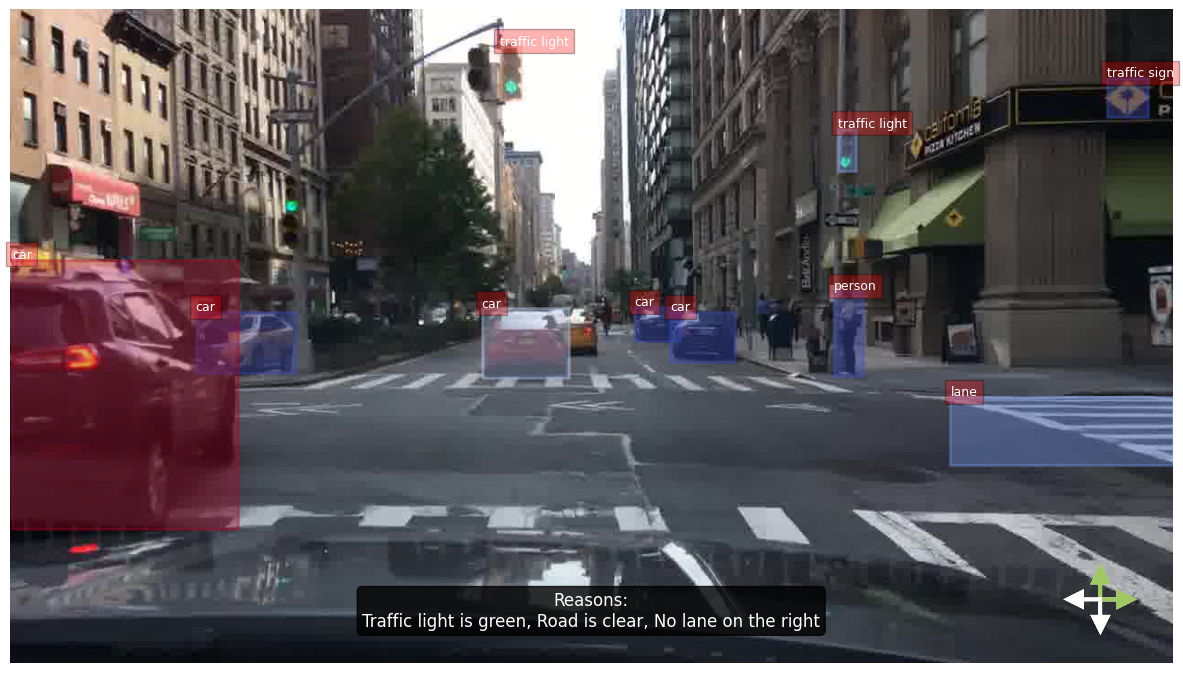

In [133]:
# visualize a sample
test_loader = DataLoader(bddoia_test, batch_size=1, num_workers=1, shuffle=True)
sample = next(iter(test_loader))
img = Image.open(os.path.join("/content/content/BDD-OIA/BDD-OIA", "data", sample["file_name"][0])).convert('RGB')
pred_actions, pred_reasons, weights = model(sample["global_image"], sample["object_crops"], sample["object_prompts"])
weights = weights[0].detach().cpu().numpy()[0]
w_min = weights.min()
w_max = weights.max()
if w_max > w_min:
    norm_weights = (weights - w_min) / (w_max - w_min)
else:
    norm_weights = np.ones_like(weights) * 0.5
visualize_sample(img, sample["bounding_boxes"], [id_to_label[x.item()] for x in sample["bounding_boxes_labels"]], None, sample["actions"].tolist(), sample["reasons"], norm_weights)

In [135]:
print(sample["file_name"])

['5d27f0e4-56996797_1.jpg']
